##IMPORT LIBRARY

In [1]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from PIL import Image
from skimage.transform import rotate
from skimage.exposure import adjust_gamma

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

##DOWNLOAD DATASET

In [2]:
!pip install kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d nexuswho/tomatofruits

!unzip tomatofruits.zip -d tomatofruits

Saving kaggle (1).json to kaggle (1).json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/nexuswho/tomatofruits
License(s): other
100% 156M/156M [00:04<00:00, 37.3MB/s]

Archive:  tomatofruits.zip
  inflating: tomatofruits/Three Classes/Reject/reject (1).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (10).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (100).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (101).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (102).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (103).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (104).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (105).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (106).jpg  
  inflating: tomatofruits/Three Classes/Reject/reject (107).jpg  
  inflating: tom

##HAPUS FOLDER TWO CLASSES

In [3]:
folder = "tomatofruits/Two Classes"

if os.path.exists(folder):
    shutil.rmtree(folder)

print("Selesai")

Selesai


##AUGMENTASI MANUAL

In [4]:
def rotate_image(img):
    angle = random.randint(-15, 15)
    return rotate(img, angle)

def brighten(img):
    return adjust_gamma(img, gamma=0.8)

augment_functions = [
    rotate_image,
    brighten
]

source_dir = "./tomatofruits/Three Classes"
output_dir = "./augmented_dataset"

classes = ["Reject", "Ripe", "Unripe"]

TARGET = 5000

os.makedirs(output_dir, exist_ok=True)

for cls in classes:

    src = os.path.join(source_dir, cls)
    dst = os.path.join(output_dir, cls)

    os.makedirs(dst, exist_ok=True)

    images = os.listdir(src)

    print(f"\nProcessing {cls}")

    for img_name in images:

        path = os.path.join(src, img_name)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))

        save_path = os.path.join(dst, img_name)

        cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    current_count = len(os.listdir(dst))

    while current_count < TARGET:

        img_name = random.choice(images)

        path = os.path.join(src, img_name)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))

        func = random.choice(augment_functions)

        aug = func(img)

        aug = (aug * 255).astype(np.uint8)

        new_name = f"aug_{current_count}.jpg"

        cv2.imwrite(
            os.path.join(dst, new_name),
            cv2.cvtColor(aug, cv2.COLOR_RGB2BGR)
        )

        current_count += 1

print("Augmentasi selesai")


Processing Reject

Processing Ripe

Processing Unripe
Augmentasi selesai


##SPLIT DATASET

In [5]:
base_dir = "./augmented_dataset"

output_dir = "./tomato_split"

train_dir = os.path.join(output_dir, "train")
valid_dir = os.path.join(output_dir, "valid")
test_dir  = os.path.join(output_dir, "test")

for folder in [train_dir, valid_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

for cls in classes:

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(valid_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    src = os.path.join(base_dir, cls)

    images = os.listdir(src)

    random.shuffle(images)

    train_split = int(0.7 * len(images))
    valid_split = int(0.2 * len(images))

    train_imgs = images[:train_split]
    valid_imgs = images[train_split:train_split+valid_split]
    test_imgs  = images[train_split+valid_split:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(train_dir, cls, img)
        )

    for img in valid_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(valid_dir, cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(test_dir, cls, img)
        )

print("Split selesai")

Split selesai


##GENERATOR

In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = valid_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=1,
    shuffle=False,
    class_mode='categorical'
)

Found 10500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


##MODEL

In [7]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dropout(0.2),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

##CALLBACK

In [8]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3
    )
]

##TRAINING

In [9]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=50, #before 30
    callbacks=callbacks
)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 77s 164ms/step - accuracy: 0.7381 - loss: 0.6692 - val_accuracy: 0.8663 - val_loss: 0.3548 - learning_rate: 1.0000e-04
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.8331 - loss: 0.4319 - val_accuracy: 0.8853 - val_loss: 0.2986 - learning_rate: 1.0000e-04
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.8512 - loss: 0.3787 - val_accuracy: 0.8983 - val_loss: 0.2749 - learning_rate: 1.0000e-04
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.8667 - loss: 0.3482 - val_accuracy: 0.9007 - val_loss: 0.2543 - learning_rate: 1.0000e-04
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.8770 - loss: 0.3193 - val_accuracy: 0.9067 - val_loss: 0.2406 - learning_rate: 1.0000e-04
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.8822 - loss: 0.3016 - val_accuracy: 0.9087 - val_loss: 0.2254 - learning_rate: 1.0000e-04
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/st

##FINE TUNING

In [10]:
# base_model.trainable = True

# for layer in base_model.layers[:-15]:
#     layer.trainable = False

# model.compile(
#     optimizer=Adam(1e-6),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_ft = model.fit(
#     train_generator,
#     validation_data=valid_generator,
#     epochs=15,
#     callbacks=callbacks
# )

##PLOT GRAPH

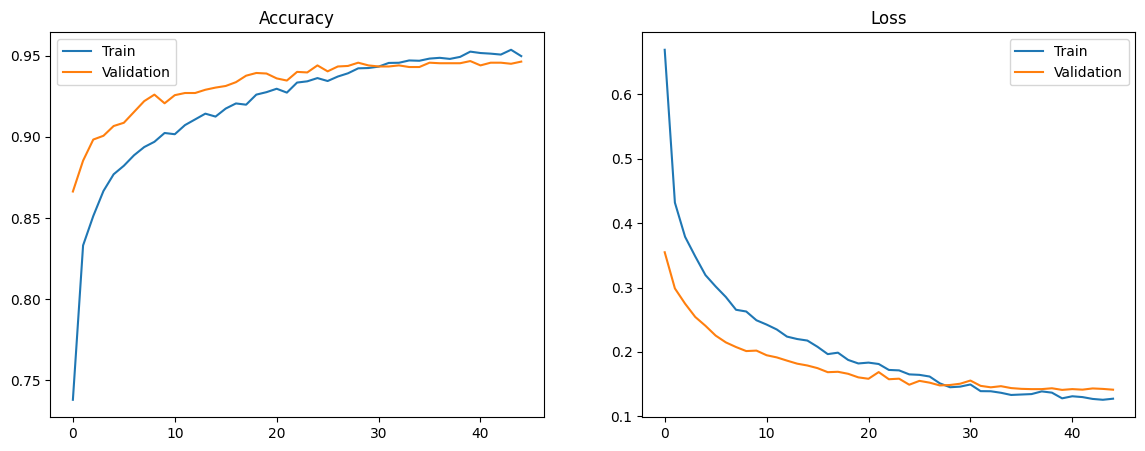

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

##EVALUASI

In [13]:
loss, acc = model.evaluate(test_generator)

print("Test Accuracy :", acc)
print("Test Loss :", loss)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.9567 - loss: 0.1179
Test Accuracy : 0.9566666483879089
Test Loss : 0.11788579076528549


##CONFUSION MATRIX

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step


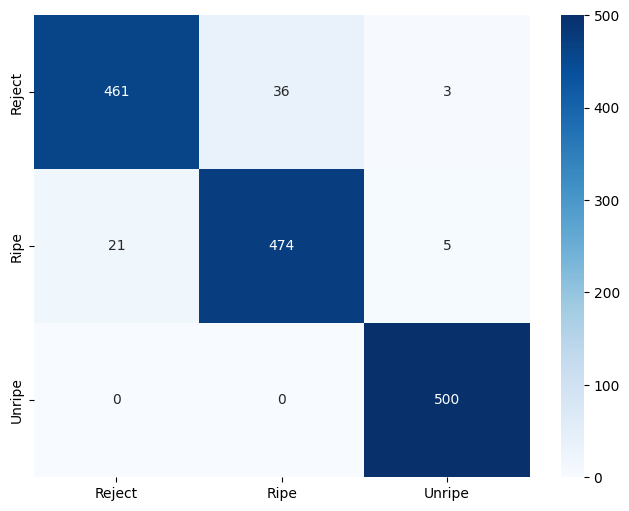

              precision    recall  f1-score   support

      Reject       0.96      0.92      0.94       500
        Ripe       0.93      0.95      0.94       500
      Unripe       0.98      1.00      0.99       500

    accuracy                           0.96      1500
   macro avg       0.96      0.96      0.96      1500
weighted avg       0.96      0.96      0.96      1500



In [14]:
pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.show()

print(classification_report(
    true_classes,
    pred_classes,
    target_names=labels
))

In [15]:
model.save_weights("tomato4.weights.h5")